# Kinetyka chemiczna - modele w Python


### Przykład 1. Kinetyka pierwszego rzędu
Rozważmy reakcję pierwszego rzędu:

$$ A \rightarrow B $$


$$-\frac{d[A]}{dt}=k[A]$$

rozdzielenie zmiennych i całkowanie stronami daje:


$$\int_{[A]_0}^{[A]} - \frac{1}{[A]} d[A] = ln([A]_0) - ln([A])$$

$$\int_{0}^{t}kdt = kt $$

czyli:

$$ ln([A]_0) - ln([A]) = kt $$

lub w innej postaci:

$$[A] = [A]_0\exp(-kt) $$


A teraz całkowanie numeryczne:


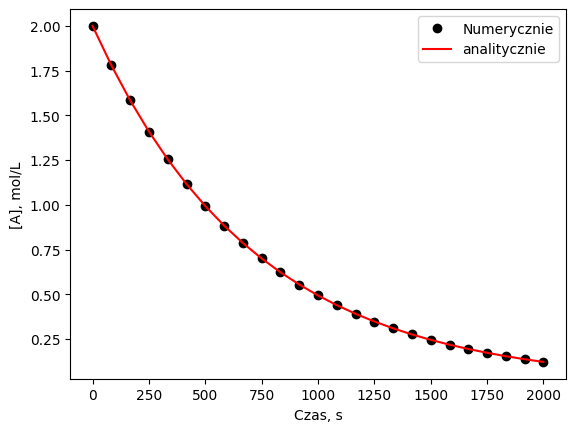

In [52]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint



k = 1.4e-3 # 1/s -- stała szybkośi

# A -> B, k
def model(y, t):
    A = y[0]
    dAdt = -k*A      # da/dt = ka
    return [dAdt]

A0 = 2 # mol/L
initial = [A0]         # [A]0 = 1.2 mol/L

t = np.linspace(0, 2000, 25) # ts => time

res = odeint( model, initial, t )
A = res[:,0]

# rozwiazanie analityczne - 'ze wzoru'
def y(t):
    return A0*np.exp(-k*t)

plt.plot(t,A,'ko', label='Numerycznie')
plt.plot(t,y(t),'r-', label='analitycznie')
plt.xlabel('Czas, s')
plt.ylabel('[A], mol/L')
plt.legend()
plt.show()

In [53]:
# znaczenie t, A

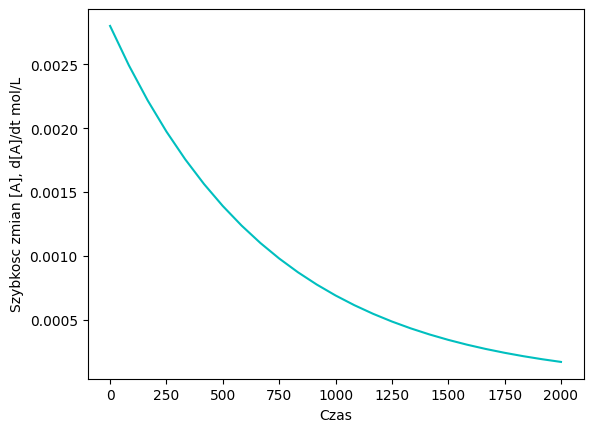

In [54]:
# szybkość reakcji


va = k*a # szybkość ubytku substratu A -- liczone z definicji (!)
plt.plot(t, va, 'c-', label='model: dA/dt = -kA')
plt.xlabel('Czas')
plt.ylabel('Szybkosc zmian [A], d[A]/dt mol/L')
plt.show()

In [60]:
# szybkość POCZĄTKOWA reakcji, dla t około 0

v0 = (A[0]-A[1])/(A[1]-A[0])

print(v0)



-1.0


### Przykład 2. Kinetyka drugiego rzędu

Text(0, 0.5, 'Stezenie reagentow')

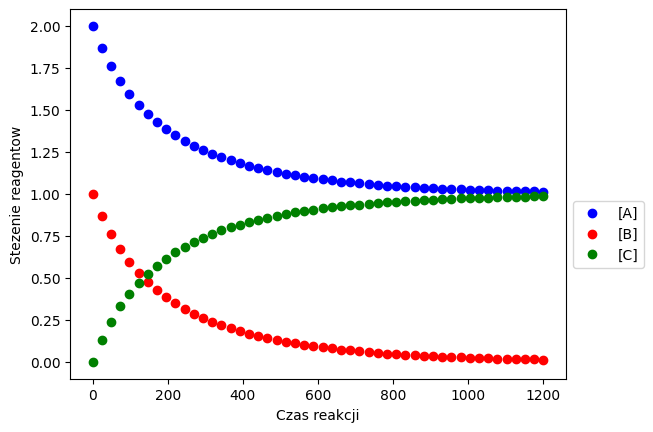

In [18]:
import matplotlib.pyplot as plt

import numpy
from scipy.integrate import odeint


# A + B -> C

def model(y, t):

    #a,b, c => stężenia [A] [B] [C]
    a = y[0]
    b = y[1]
    c = y[2]

    k1 = 3e-3

    #model kinetyczny
    dadt = -k1*a*b
    dbdt = -k1*a*b
    dcdt = k1*a*b
    return [dadt, dbdt, dcdt]


a0=2
b0=1
c0=0

initial = [a0, b0, c0]
t = numpy.linspace(0, 1200) # ts => time

res = odeint( model, initial, t )
a = res[:,0]
b = res[:,1]
c = res[:,2]

plt.plot(t,a,'bo', label='[A]')
plt.plot(t,b,'ro', label='[B]')
plt.plot(t,c,'go', label='[C]')
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Czas reakcji')
plt.ylabel('Stezenie reagentow')

**Zadanie 1.** Zbadać zachowanie się modelu dla następującego zestawów danych:

a0 | b0 | c0 | k1
--- | --- | --- | ---
1 | 1 | 0 | 3e-3
1 | 0| 0 | 3e-3
2 | 1| 0 | 3e-3



### Przykład 3. Kinetyka psudopierwszego rzędu



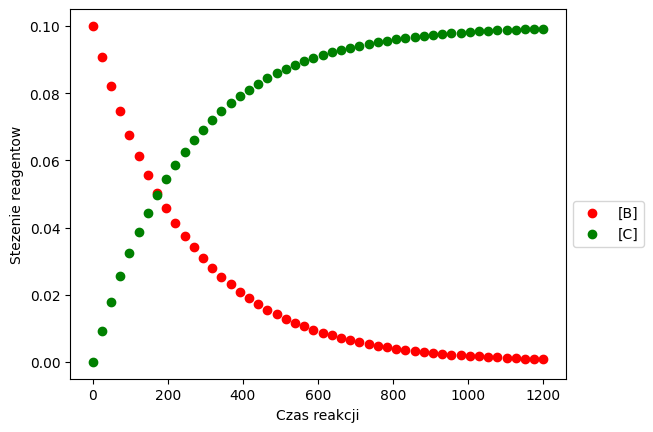

In [21]:
import matplotlib.pyplot as plt

import numpy
from scipy.integrate import odeint


# A + B -> C

def model(y, t):

    #a,b => stężenia [A] [B]
    a = y[0]
    b = y[1]
    c = y[2]

    k1 = 1e-4

    #model kinetyczny
    dadt = -k1*a*b
    dbdt = -k1*a*b
    dcdt = k1*a*b
    return [dadt, dbdt, dcdt]


a0=40
b0=0.1
c0=0

initial = [a0, b0, c0]
t = numpy.linspace(0, 1200) # ts => time

res = odeint( model, initial, t )
A = res[:,0]
B = res[:,1]
C = res[:,2]

#plt.plot(t,A,'bo', label='[A]')
plt.plot(t,B,'ro', label='[B]')
plt.plot(t,C,'go', label='[C]')
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Czas reakcji')
plt.ylabel('Stezenie reagentow')
plt.show()

In [22]:
alfa_a = 100-100*a[-1]/a[0] #a[-1] ostatni element w vektorze a, -1 to indeks ostatniego elementu
alfa_b = 100-100*b[-1]/b[0]

print("Konwersja końcowa A: {0:.2f}%, konwersja B: {1:.2f}%".format(alfa_a, alfa_b))


Konwersja końcowa A: 0.25%, konwersja B: 99.17%


In [23]:
#szybkość początkowa
v0 = (b[1] - b[0])/(t[1]-t[0])


print(v0)

-0.0003809890652063457


Text(0, 0.5, 'Stezenie reagentow')

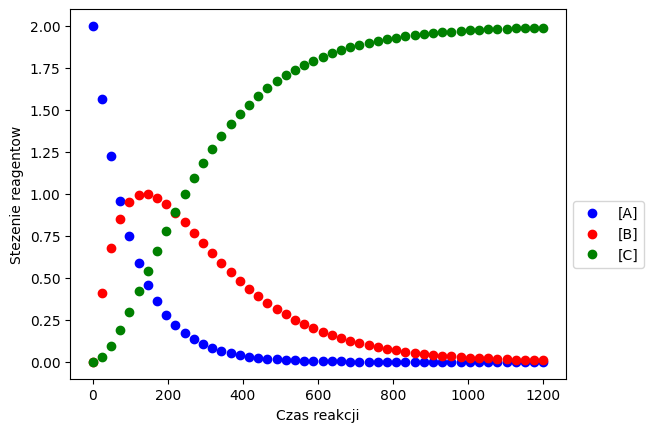

In [26]:

import matplotlib.pyplot as plt

import numpy
from scipy.integrate import odeint


# A -> B -> C

def model(y, t):

    #A,B,C => stężenia [A] [B]
    A = y[0]
    B = y[1]
    C = y[2]

    k1 = 1e-2
    k2 = 5e-3

    #model kinetyczny
    dAdt = -k1*A         # da/dt = -k1A
    dBdt = k1*A - k2*B   # db/dt = k1A-k2B
    dCdt = k2*B          # dc/dt = k2B
    return [dAdt, dBdt, dCdt]



initial = [2,0,0]
t = numpy.linspace(0, 1200) # ts => time

results = odeint( model, initial, t )
A = results[:,0]
B = results[:,1]
C = results[:,2]

plt.plot(t,A,'bo', label='[A]')
plt.plot(t,B,'ro', label='[B]')
plt.plot(t,C,'go', label='[C]')
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Czas reakcji')
plt.ylabel('Stezenie reagentow')

**Zadanie 4.** Opracować model kinetyczny dla reakcji równoległych:
$$ A \rightarrow B , k_1=1\cdot10^{-2}$$

$$ A \rightarrow C, k_2=2\cdot10^{-2}$$

Rozwiązać numerycznie układy równań dla t = 0 ... 1200. Zrobić wykres.


**Zadanie 5.** Opracować model kinetyczny dla reakcji równowagowych:

$$ A \rightarrow B, k_1=4\cdot10^{-3} $$

$$ B \rightarrow A, k_2=5\cdot10^{-3} $$

Rozwiązać numerycznie układy równań dla t = 0 ... 1200. Zrobić wykres.

In [34]:
# rozwiązanie zadania 5



















### Przykład 4. Kolejne modele kinetyczne


$$ 2A \rightarrow B , k_1=4\cdot10^{-3}$$



Text(0, 0.5, 'Stezenie reagentow')

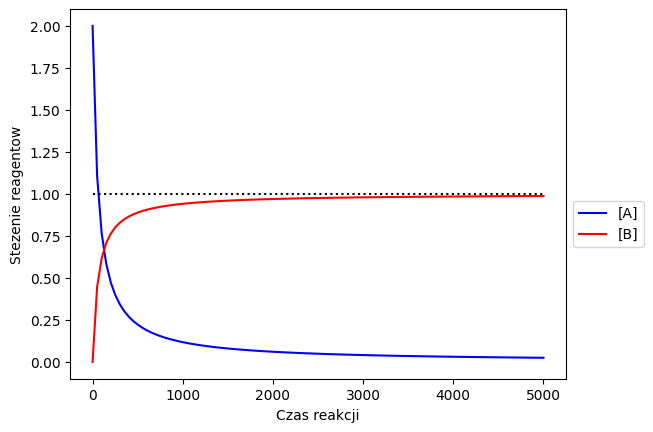

In [27]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy
from scipy.integrate import odeint


# 2A ---> B, k1
# co jest równoważne:
# A + A -----> B, k1
# czyli:

def model(y, t):

    #a,b => stężenia [A] [B]
    a = y[0]
    b = y[1]

    k1 = 4e-3

    #model kinetyczny
    dadt = -k1*a*a - k1*a*a
    dbdt = k1*a*a
    return [dadt, dbdt]


a0=2
b0=0

ts = 0
te = 5000

initial = [a0,b0]
t = numpy.linspace(ts, te,100)

res = odeint( model, initial, t )
a = res[:,0]
b = res[:,1]


plt.plot(t,a,'b-', label='[A]')
plt.plot(t,b,'r-', label='[B]')
plt.plot((ts, te),(0.5*a0, 0.5*a0),'k:')

plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Czas reakcji')
plt.ylabel('Stezenie reagentow')


In [28]:
# sprawdzenie --- bilans masy

print(a + 2*b)

[2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2.]


---

$$ 2A \rightarrow B, k_1=8\cdot10^{-4} $$
$$ B \rightarrow 2A, k_2=2\cdot10^{-4} $$

$$ t = 0 ... 5000 $$

Text(0, 0.5, 'Stezenie reagentow')

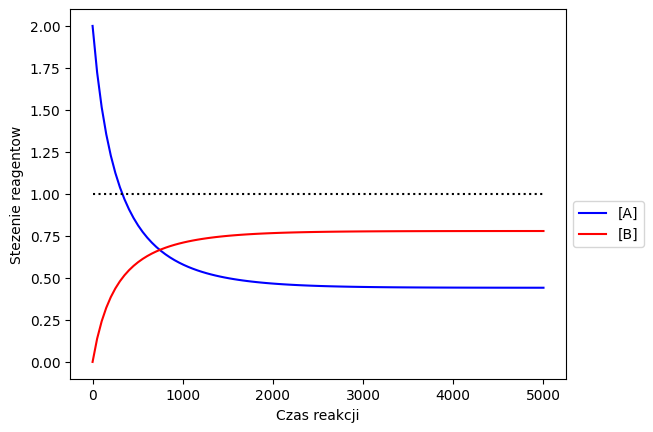

In [29]:
import matplotlib.pyplot as plt

import numpy
from scipy.integrate import odeint


# 2A <---> B, k1, k2
# co jest równoważne:
# A + A -----> B, k1
# B -----> A + A, k2
# czyli:

def model(y, t):

    #a,b => stężenia [A] [B]
    a = y[0]
    b = y[1]

    k1 = 8e-4
    k2 = 2e-4

    #model kinetyczny
    dadt = -k1*a*a - k1*a*a + k2*b + k2*b
    dbdt = k1*a*a - k2*b
    return [dadt, dbdt]


a0=2
b0=0

ts = 0
te = 5000

initial = [a0,b0]
t = numpy.linspace(ts, te,100)

res = odeint( model, initial, t )
a = res[:,0]
b = res[:,1]


plt.plot(t,a,'b-', label='[A]')
plt.plot(t,b,'r-', label='[B]')
plt.plot((ts, te),(0.5*a0, 0.5*a0),'k:')

plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Czas reakcji')
plt.ylabel('Stezenie reagentow')


In [30]:
# sprawdzenie == bilans masy
# czy [A] + 2*[B] = const ?
print(a+2*b)

[2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2.]


### Przykład 5. Reakcje autokatalityczne

Text(0, 0.5, 'Stezenie reagentow')

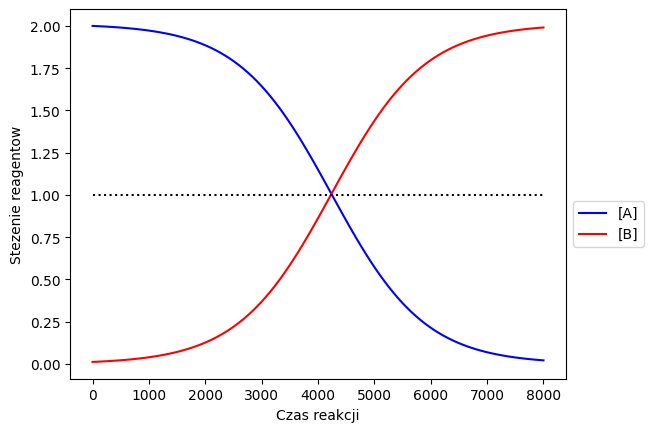

In [32]:
import matplotlib.pyplot as plt

import numpy
from scipy.integrate import odeint

# Reakcje autokatalityczne to takie reakcje, w których
# co najmniej jeden z produktów jest jednocześnie substratem.
# A + B ---> 2B k1

k1 = 6e-4

def model(y, t):

    #a,b => stężenia [A] [B]
    a = y[0]
    b = y[1]

    #model kinetyczny
    dadt = -k1*a*b
    dbdt =  k1*a*b
    return [dadt, dbdt]


a0=2
b0=0.012

ts = 0
te = 8000

initial = [a0,b0]
t = numpy.linspace(ts, te,100)

res = odeint( model, initial, t )
a = res[:,0]
b = res[:,1]


plt.plot(t,a,'b-', label='[A]')
plt.plot(t,b,'r-', label='[B]')
plt.plot((ts, te),(0.5*a0, 0.5*a0),'k:')

plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Czas reakcji')
plt.ylabel('Stezenie reagentow')


**Zadanie 5.** Prześledzić zależność szybkości reakcji autokatalitycznej v w funkcji czasu (sporządzić wykres). Czy zaobserwowane zjawisko jest sprzeczne z prawami kinetyki chemicznej?

Odpowiedź jest poniżej - zajrzeć w ostateczności ...

Text(0, 0.5, 'Szybkosc reakcji autokatalitycznej, mol/Ls')

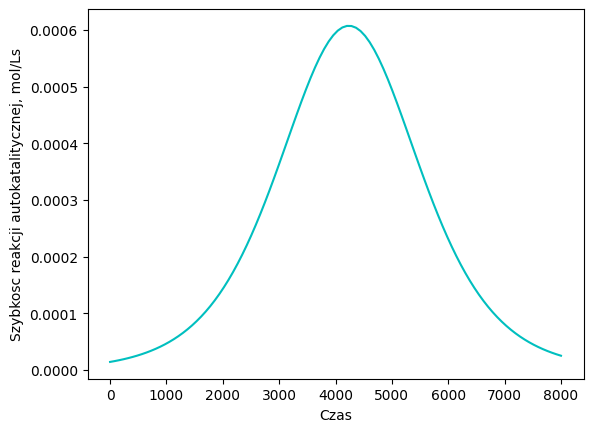

In [ ]:
plt.plot(t,k1*a*b, 'c-')
plt.xlabel('Czas')
plt.ylabel('Szybkosc reakcji autokatalitycznej, mol/Ls')